<a href="https://colab.research.google.com/github/aminmoosavi/__PyTorch__/blob/main/PyTorch_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PyTorch Day-2**

* **In this notebook we will repeat what we did in Day-1 (fitting a quadratic model) but using a two layer network**

* **When training the model, we assume we do not know anything about the data**

* **We also look at the issue of generalization**


In [1]:
import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt

* # Creating the data
We are looking at a quadratic model with Gaussian noise ($\eta$)

$ y = ax^2 +bx +c + \eta$

The goal is to find a two layer model that replicates the quadratic behavior

In [2]:
# True parameters
a = 1.0
b = -2.0
c = 4.0

# Input data
X = torch.arange(start = -2 , end = 4 , step = 0.01).unsqueeze(dim=1)

# Setting the random seed
torch.manual_seed(21)

# Observed output
Y = a * X**2 + b * X + c + torch.randn(X.size())

* # Splitting the data into training and test sets

In [3]:
# Generating a shuffled data indices
shuffled_indices = torch.randperm(X.size()[0])

# Use 75 percent of the data points for training and 25 percent for testing
# We could have a validation set (Will get back to this in the future)
train_split = int(0.75 * len(X))

# Splitting the data
X_train , Y_trian = X[shuffled_indices[:train_split]] , Y[shuffled_indices[:train_split]]
X_test , Y_test = X[shuffled_indices[train_split:]] , Y[shuffled_indices[train_split:]]

* # Visualize the data

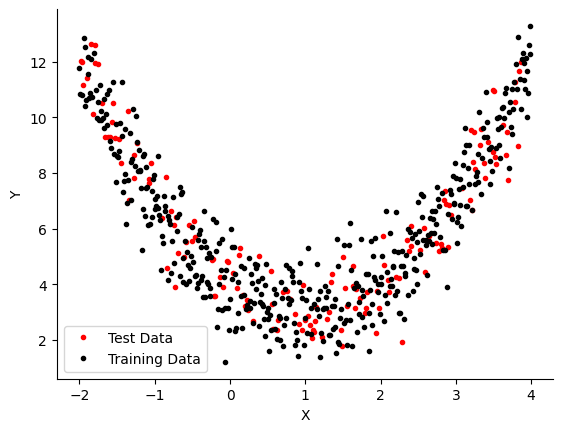

In [4]:
fig, ax = plt.subplots()
ax.plot(X_test,Y_test,'r.',label='Test Data')
ax.plot(X_train,Y_trian,'k.',label='Training Data')
ax.set_ylabel('Y')
ax.set_xlabel('X')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()

* # Build the model

In [5]:
class QuadraticRegressionBilayer(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer1 = nn.Linear(in_features=1 , out_features=1000)
    self.activation = nn.GELU()
    self.layer2 = nn.Linear(in_features=1000 , out_features=1)



  def forward(self, x: torch.Tensor) -> torch.Tensor:
    x = self.layer1(x)
    x = self.activation(x)
    x = self.layer2(x)
    return x

In [6]:
# instantiating the model
torch.manual_seed(2)
model_2 = QuadraticRegressionBilayer()

# model_2.state_dict()


In [7]:
Y_pred = model_2(X_train)

* # Select the loss function

In [8]:
# Mean Squared Error loss function:
loss_fn = nn.MSELoss()

* # Select the optimizer

In [9]:
# The SGD optimizer. lr is the learning rate
optimizer = torch.optim.SGD(params=model_2.parameters(),
                            lr=0.0002)

* # Training loop

In [10]:
epochs = 1500
losses=torch.zeros(epochs)
losses_test=torch.zeros(epochs)
for epoch in range(epochs):
  model_2.train() # training mode activated

  #1. forward pass
  Y_pred = model_2(X_train)

  #2. Compute the loss
  loss=loss_fn(Y_pred,Y_trian)
  losses[epoch]=loss # save the loss

  #3. Optimizer zero grad resets the gradient to zero
  optimizer.zero_grad()

  #4. Perform backpropagation
  loss.backward()

  #5. Step the optimizer (gradient descent)
  optimizer.step()

  #6. Look at how the model does on the test data
  model_2.eval() # Evaluation mode activated
  with torch.inference_mode():
    # forward pass the test data
    Y_pred_test = model_2(X_test)

    # calculate test loss
    loss_test=loss_fn(Y_pred_test,Y_test)
    losses_test[epoch] = loss_test # save the loss

* # Visualizing the loss function

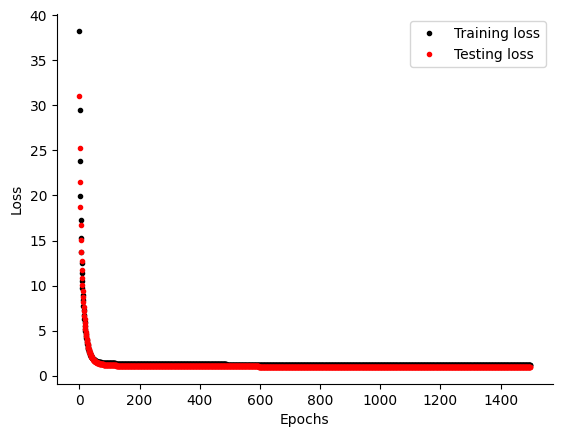

In [11]:
# Casting the loss tensors into NumPy arrays
lossvals=losses.detach().numpy()
lossvals_test=losses_test.detach().numpy()

# Plotting the loss functions
fig, ax = plt.subplots()
plt.plot(lossvals,'.',color='k',label = 'Training loss')
ax.plot(lossvals_test,'.',color='r',label = 'Testing loss')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()
plt.show()



* # Testing and generalization
In the figure below, we see that the two-layer network does a relatively good job at predicting data within the training data domain but fails to predict data points outside that (poor generalization).


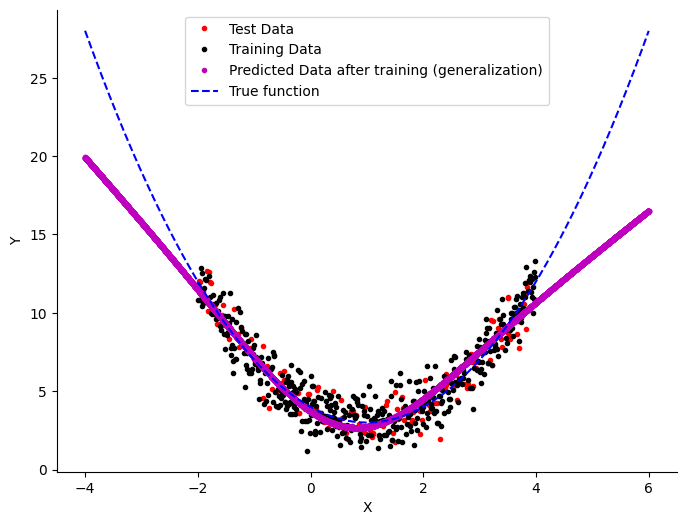

In [12]:
X_test_outof_domain = torch.arange(start = -4 , end = 6. , step = 0.001).unsqueeze(dim=1)
Y_true = a *  X_test_outof_domain**2 + b* X_test_outof_domain + c
with torch.inference_mode():
  y_preds = model_2(X_test)
  y_preds_outof_domain = model_2(X_test_outof_domain)


fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(X_test,Y_test,'r.',label='Test Data')
ax.plot(X_train,Y_trian,'k.',label='Training Data')
# ax.plot(X_test,y_preds,'g.',label='Predicted test Data after training')
ax.plot(X_test_outof_domain,y_preds_outof_domain,'m.',label='Predicted Data after training (generalization)')
ax.plot(X_test_outof_domain,Y_true,'--b',label='True function')
ax.set_ylabel('Y')
ax.set_xlabel('X')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()
plt.show()